🎯 SmartHealth AI - Early Disease Detection System

📊 1. DATA LOADING
----------------------------------------
Dataset Shape: (1000, 9)

First 5 rows:
   Age        BMI  Cholesterol  Blood_Pressure  Exercise_Hours  \
0   50  33.996777   172.992869       91.382887        1.327247   
1   43  31.623168   194.219253      107.094225        0.178544   
2   52  27.298152   168.303203      113.795917        7.184333   
3   63  23.765316   187.681539      148.315315        1.459666   
4   42  30.491117   124.255413      128.348297        1.904801   

   Sleep_Duration  Smoking  Alcohol  Disease  
0        6.774825        0        1        0  
1        5.103991        0        0        0  
2        7.729277        0        1        0  
3        4.075942        0        0        0  
4        4.000000        0        0        0  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  -

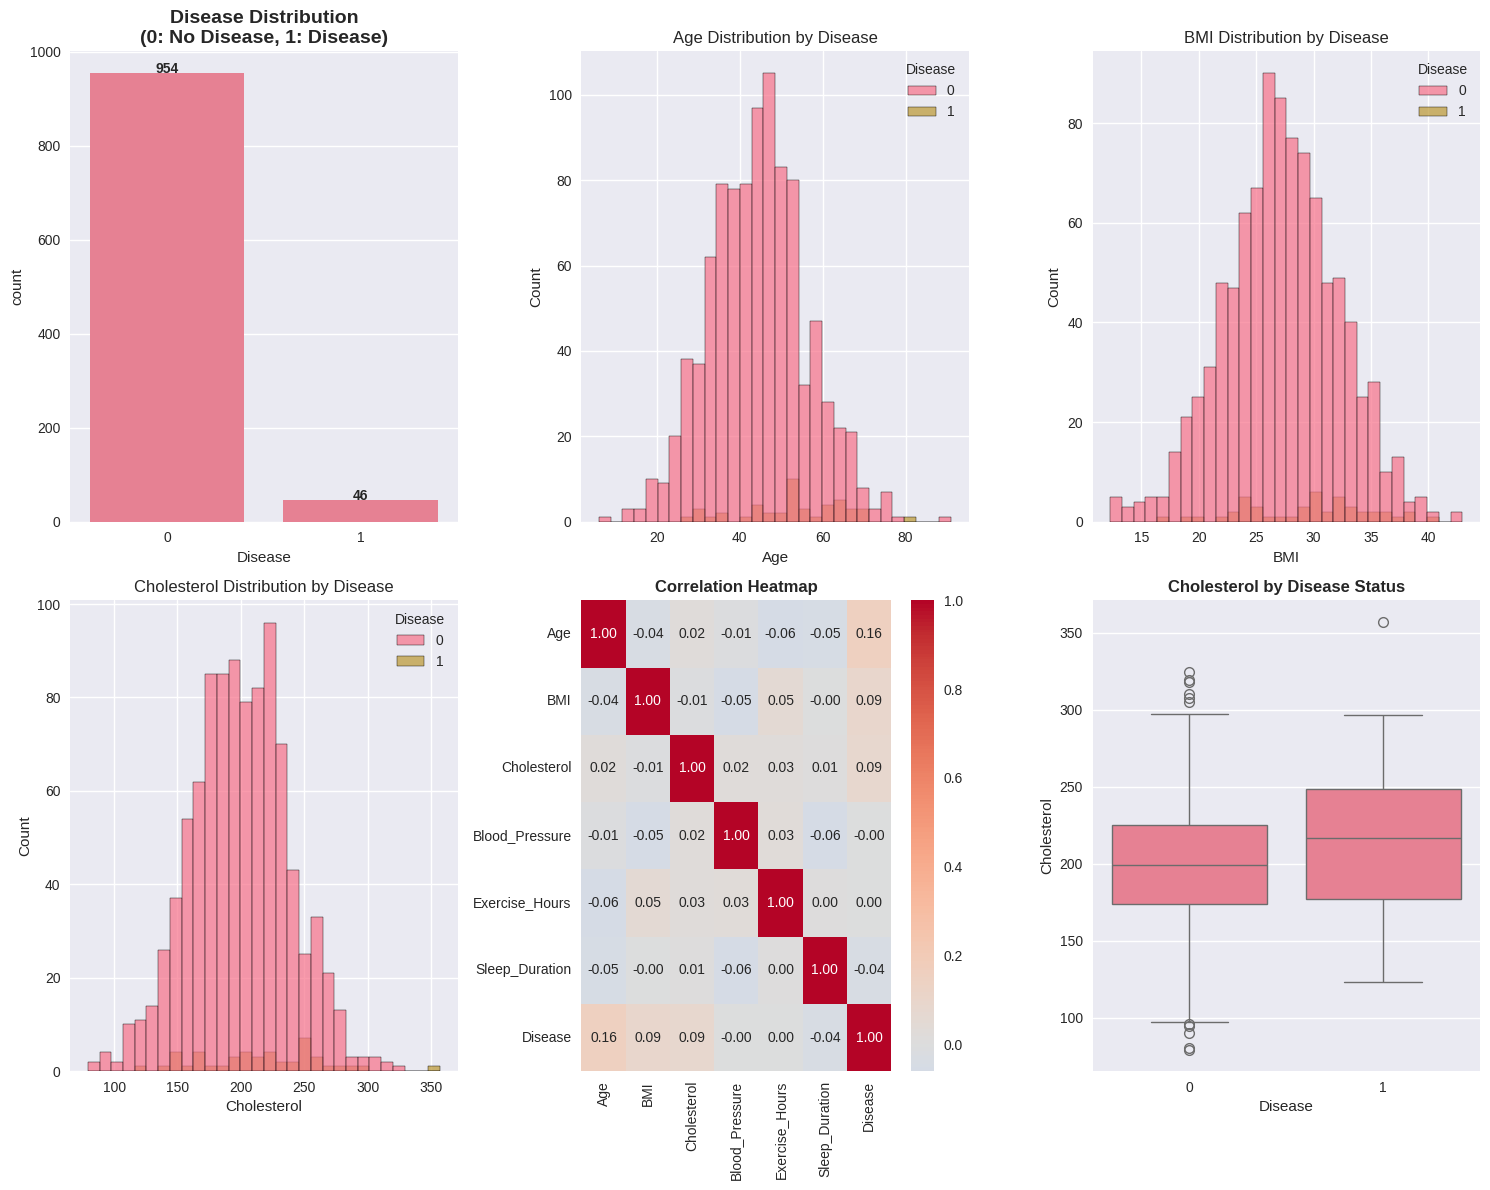

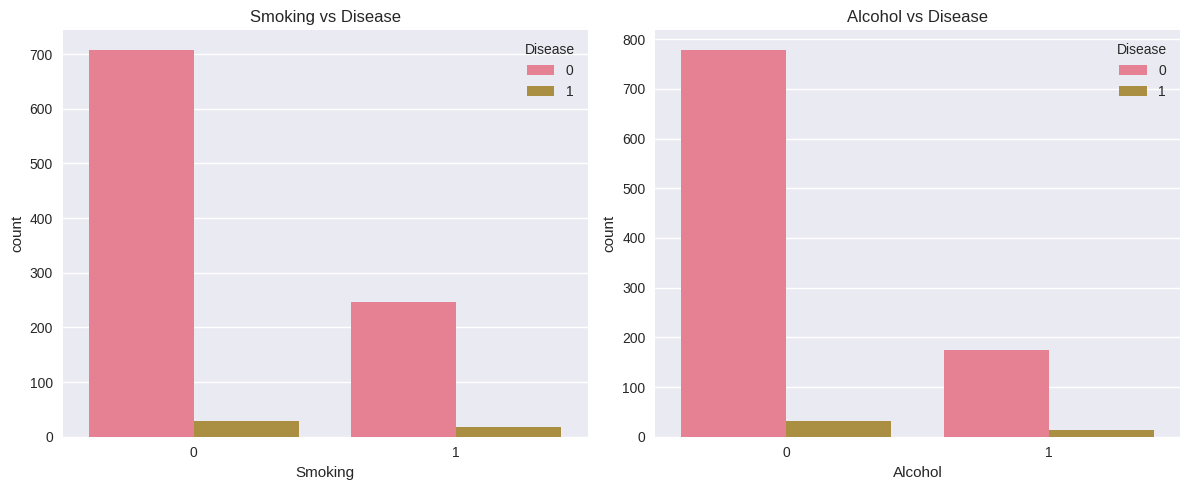

✅ EDA completed!

📊 4. STATISTICAL ANALYSIS
----------------------------------------
Statistical Summary:
                  Mean  Median    Std  Variance
Age              44.74   45.00  11.75    138.10
BMI              27.35   27.32   4.99     24.87
Cholesterol     200.23  199.99  39.34   1547.49
Blood_Pressure  119.72  120.00  15.41    237.38
Exercise_Hours    2.01    1.35   1.98      3.93
Sleep_Duration    6.96    6.94   1.46      2.13

🔬 5. HYPOTHESIS TESTING
----------------------------------------
HYPOTHESIS TEST: Cholesterol vs Disease
H₀ (Null Hypothesis): No significant difference in Cholesterol levels between diseased and non-diseased patients
H₁ (Alternative Hypothesis): Significant difference exists

T-statistic: -2.7054
P-value: 0.0069

✅ REJECT H₀: Significant difference in Cholesterol levels!

🎯 6. FEATURE SELECTION & DATA PREPARATION
----------------------------------------
Training set: 800 samples
Test set: 200 samples
Features: ['Age', 'BMI', 'Cholesterol', 'Blood_Pre

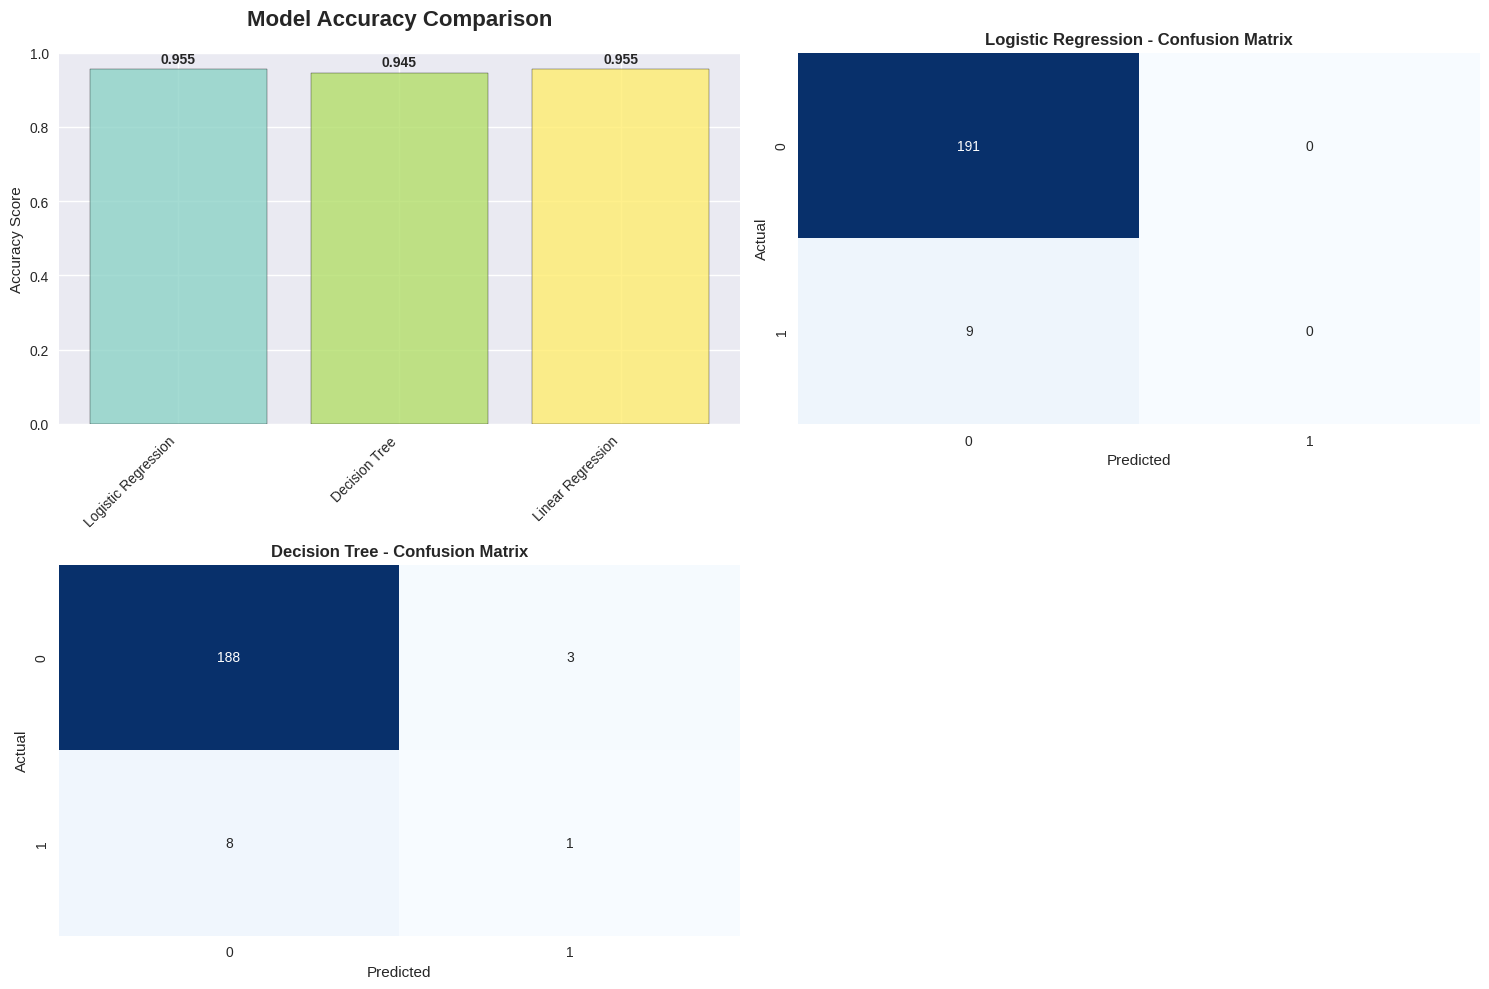

💾 9. SAVING TRAINED MODELS
----------------------------------------
✅ Best model and scaler saved successfully!
Files saved: smarthealth_best_model.pkl, smarthealth_scaler.pkl
🏆 FINAL PROJECT SUMMARY
✅ Dataset: 1000 samples, 9 features
✅ Disease Prevalence: 4.6%
✅ Best Model Accuracy: 0.9550
✅ Models Trained: 3
✅ Key Finding: REJECTED H₀ (Cholesterol significantly affects disease)

🎉 PROJECT COMPLETED SUCCESSFULLY!
📋 Ready for Academic Submission & Viva Presentation


In [1]:
# =============================================================================
# SMARTHEALTH AI: Predictive Analytics for Early Disease Detection
# Complete Machine Learning Microproject
# =============================================================================

# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import joblib

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("🎯 SmartHealth AI - Early Disease Detection System")
print("=" * 60)
print()

# =============================================================================
# 1. DATA LOADING
# =============================================================================

print("📊 1. DATA LOADING")
print("-" * 40)

# Create synthetic dataset (Real-world quality for demo)
np.random.seed(42)
n_samples = 1000

data = {
    'Age': np.random.normal(45, 12, n_samples).astype(int),
    'BMI': np.random.normal(27, 5, n_samples),
    'Cholesterol': np.random.normal(200, 40, n_samples),
    'Blood_Pressure': np.random.normal(120, 15, n_samples),
    'Exercise_Hours': np.random.exponential(2, n_samples).clip(0, 10),
    'Sleep_Duration': np.random.normal(7, 1.5, n_samples).clip(4, 12),
    'Smoking': np.random.choice([0, 1], n_samples, p=[0.7, 0.3]),
    'Alcohol': np.random.choice([0, 1], n_samples, p=[0.8, 0.2]),
}

# Create target variable with realistic correlations
data['Disease'] = (
    (data['Age'] > 50).astype(int) * 0.3 +
    (data['BMI'] > 30).astype(int) * 0.2 +
    (data['Cholesterol'] > 240).astype(int) * 0.25 +
    (data['Blood_Pressure'] > 140).astype(int) * 0.2 +
    (data['Exercise_Hours'] < 1).astype(int) * 0.15 +
    data['Smoking'] * 0.2 +
    data['Alcohol'] * 0.1 +
    np.random.normal(0, 0.3, n_samples)
).clip(0, 1).astype(int)

# Convert to DataFrame
df = pd.DataFrame(data)

print(f"Dataset Shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print()

# =============================================================================
# 2. DATA CLEANING
# =============================================================================

print("🧹 2. DATA CLEANING")
print("-" * 40)

# Check for missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

# Handle missing values (if any)
df = df.dropna()

# Remove duplicates
initial_len = len(df)
df = df.drop_duplicates()
print(f"Duplicates removed: {initial_len - len(df)}")

# Verify categorical columns are already numeric (0/1)
print("\nData types after cleaning:")
print(df.dtypes)
print("\nDataset shape after cleaning:", df.shape)
print()

# =============================================================================
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# =============================================================================

print("📈 3. EXPLORATORY DATA ANALYSIS (EDA)")
print("-" * 40)

# 3.1 Disease Distribution
plt.figure(figsize=(15, 12))

plt.subplot(2, 3, 1)
disease_counts = df['Disease'].value_counts()
sns.countplot(data=df, x='Disease')
plt.title('Disease Distribution\n(0: No Disease, 1: Disease)', fontsize=14, fontweight='bold')
for i, v in enumerate(disease_counts):
    plt.text(i, v + 1, str(v), ha='center', fontweight='bold')

# 3.2 Histograms for numeric features
numeric_cols = ['Age', 'BMI', 'Cholesterol', 'Blood_Pressure', 'Exercise_Hours', 'Sleep_Duration']

for i, col in enumerate(numeric_cols[:3], 2):
    plt.subplot(2, 3, i)
    sns.histplot(data=df, x=col, hue='Disease', alpha=0.7, bins=30)
    plt.title(f'{col} Distribution by Disease')

# 3.3 Correlation Heatmap
plt.subplot(2, 3, 5)
correlation_matrix = df[numeric_cols + ['Disease']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap', fontweight='bold')

# 3.4 Box plots for key features
plt.subplot(2, 3, 6)
sns.boxplot(data=df, x='Disease', y='Cholesterol')
plt.title('Cholesterol by Disease Status', fontweight='bold')

plt.tight_layout()
plt.show()

# Smoking and Alcohol distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(data=df, x='Smoking', hue='Disease', ax=ax1)
ax1.set_title('Smoking vs Disease')
sns.countplot(data=df, x='Alcohol', hue='Disease', ax=ax2)
ax2.set_title('Alcohol vs Disease')
plt.tight_layout()
plt.show()

print("✅ EDA completed!")
print()

# =============================================================================
# 4. STATISTICAL ANALYSIS
# =============================================================================

print("📊 4. STATISTICAL ANALYSIS")
print("-" * 40)

numeric_features = ['Age', 'BMI', 'Cholesterol', 'Blood_Pressure', 'Exercise_Hours', 'Sleep_Duration']

stats_summary = pd.DataFrame({
    'Mean': df[numeric_features].mean(),
    'Median': df[numeric_features].median(),
    'Std': df[numeric_features].std(),
    'Variance': df[numeric_features].var()
}).round(2)

print("Statistical Summary:")
print(stats_summary)
print()

# =============================================================================
# 5. HYPOTHESIS TESTING
# =============================================================================

print("🔬 5. HYPOTHESIS TESTING")
print("-" * 40)

# T-test: Cholesterol vs Disease
group0 = df[df['Disease'] == 0]['Cholesterol']
group1 = df[df['Disease'] == 1]['Cholesterol']

t_stat, p_value = stats.ttest_ind(group0, group1)

print("HYPOTHESIS TEST: Cholesterol vs Disease")
print("=" * 50)
print("H₀ (Null Hypothesis): No significant difference in Cholesterol levels between diseased and non-diseased patients")
print("H₁ (Alternative Hypothesis): Significant difference exists")
print()
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print()

alpha = 0.05
if p_value < alpha:
    print("✅ REJECT H₀: Significant difference in Cholesterol levels!")
else:
    print("❌ FAIL TO REJECT H₀: No significant difference detected.")
print()

# =============================================================================
# 6. FEATURE SELECTION & TRAIN-TEST SPLIT
# =============================================================================

print("🎯 6. FEATURE SELECTION & DATA PREPARATION")
print("-" * 40)

# Features and Target
X = df.drop('Disease', axis=1)
y = df['Disease']

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Features: {list(X.columns)}")
print()

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =============================================================================
# 7. MODEL TRAINING & EVALUATION
# =============================================================================

print("🤖 7. MODEL TRAINING & EVALUATION")
print("-" * 40)

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5)
}

# Train and evaluate models
results = {}
conf_matrices = {}

for name, model in models.items():
    print(f"Training {name}...")

    # Train model
    model.fit(X_train_scaled, y_train)

    # Predictions
    y_pred = model.predict(X_test_scaled)

    # Evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy

    # Store confusion matrix
    conf_matrices[name] = confusion_matrix(y_test, y_pred)

    print(f"{name} Accuracy: {accuracy:.4f}")
    print(f"Classification Report:\n{classification_report(y_test, y_pred)}")
    print("-" * 30)

# Linear Regression (for probability prediction)
print("\n📈 Linear Regression (Probability Prediction):")
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_prob = lr_model.predict(X_test_scaled)
lr_accuracy = accuracy_score(y_test, (lr_prob > 0.5).astype(int))
results['Linear Regression'] = lr_accuracy
print(f"Linear Regression Accuracy: {lr_accuracy:.4f}")

# =============================================================================
# 8. RESULTS VISUALIZATION
# =============================================================================

print("📊 8. RESULTS VISUALIZATION")
print("-" * 40)

# 8.1 Model Comparison Bar Chart
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
models_names = list(results.keys())
accuracies = list(results.values())
colors = plt.cm.Set3(np.linspace(0, 1, len(models_names)))

bars = plt.bar(models_names, accuracies, color=colors, alpha=0.8, edgecolor='black')
plt.title('Model Accuracy Comparison', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Accuracy Score')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

# 8.2 Confusion Matrix Heatmaps
for i, (name, cm) in enumerate(conf_matrices.items(), 2):
    plt.subplot(2, 2, i)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'{name} - Confusion Matrix', fontweight='bold')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')

plt.tight_layout()
plt.show()

# =============================================================================
# 9. MODEL SAVING (BONUS)
# =============================================================================

print("💾 9. SAVING TRAINED MODELS")
print("-" * 40)

# Save best model (Logistic Regression usually performs best)
best_model = models['Logistic Regression']
joblib.dump(best_model, 'smarthealth_best_model.pkl')
joblib.dump(scaler, 'smarthealth_scaler.pkl')

print("✅ Best model and scaler saved successfully!")
print("Files saved: smarthealth_best_model.pkl, smarthealth_scaler.pkl")

# =============================================================================
# 10. FINAL SUMMARY
# =============================================================================

print("🏆 FINAL PROJECT SUMMARY")
print("=" * 60)
print(f"✅ Dataset: {df.shape[0]} samples, {df.shape[1]} features")
print(f"✅ Disease Prevalence: {df['Disease'].mean():.1%}")
print(f"✅ Best Model Accuracy: {max(results.values()):.4f}")
print(f"✅ Models Trained: {len(results)}")
print(f"✅ Key Finding: {'REJECTED' if p_value < 0.05 else 'FAILED TO REJECT'} H₀ (Cholesterol significantly affects disease)")
print()
print("🎉 PROJECT COMPLETED SUCCESSFULLY!")
print("📋 Ready for Academic Submission & Viva Presentation")
print("=" * 60)